#  IEA Global EV Data — Предобработка данных

Ноутбук демонстрирует три ключевых этапа предобработки датасета:
1. Обработка пропусков
2. Кодирование категориальных признаков
3. Масштабирование данных


## 0. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})


## 1. Загрузка данных

In [2]:
df = pd.read_csv('IEA_EV_Data_with_missing.csv')
print(f"Размер датасета: {df.shape[0]:,} строк × {df.shape[1]} столбцов")
df.head(10)


Размер датасета: 6,746 строк × 8 столбцов


,region,category,parameter,mode,powertrain,year,unit,value
0,Australia,Historical,EV stock share,Cars,EV,2011.0,percent,0.00039
1,Australia,Historical,EV sales share,Cars,NaN,2011.0,percent,0.00650
2,Australia,Historical,EV sales,Cars,BEV,2011.0,Vehicles,49.00000
3,Australia,Historical,EV stock,Cars,BEV,2011.0,Vehicles,49.00000
4,Australia,Historical,EV stock,Cars,BEV,2012.0,Vehicles,220.00000
5,Australia,Historical,EV sales,Cars,BEV,2012.0,Vehicles,170.00000
6,Australia,Historical,EV sales share,Cars,EV,2012.0,percent,NaN
7,Australia,Historical,EV stock share,Cars,EV,2012.0,percent,0.00240
8,Australia,Historical,EV stock,Cars,NaN,2012.0,Vehicles,80.00000
9,Australia,Historical,EV sales,Cars,PHEV,2012.0,Vehicles,80.00000


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6746 entries, 0 to 6745
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   region      6746 non-null   object 
 1   category    6746 non-null   object 
 2   parameter   6746 non-null   object 
 3   mode        6746 non-null   object 
 4   powertrain  6203 non-null   object 
 5   year        6553 non-null   float64
 6   unit        6419 non-null   object 
 7   value       5906 non-null   float64
dtypes: float64(2), object(6)
memory usage: 421.8+ KB


In [4]:
print("=== Типы данных ===")
print(df.dtypes)
print("\n=== Статистика числовых признаков ===")
df.describe().round(2)


=== Типы данных ===
region         object
category       object
parameter      object
mode           object
powertrain     object
year          float64
unit           object
value         float64
dtype: object

=== Статистика числовых признаков ===


,year,value
count,6553.00,5906.00
mean,2017.65,63967.11
std,3.76,647462.69
min,2010.00,0.00
25%,2015.00,1.42
50%,2018.00,54.00
75%,2021.00,2000.00
max,2023.00,28000000.00


---
## 2. Обработка пропусков

### 2.1 Анализ пропусков


In [5]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({
    'Пропусков (шт.)': missing,
    'Пропусков (%)': missing_pct
}).query('`Пропусков (шт.)` > 0')
print(missing_df.to_string())


            Пропусков (шт.)  Пропусков (%)
powertrain              543           8.05
year                    193           2.86
unit                    327           4.85
value                   840          12.45


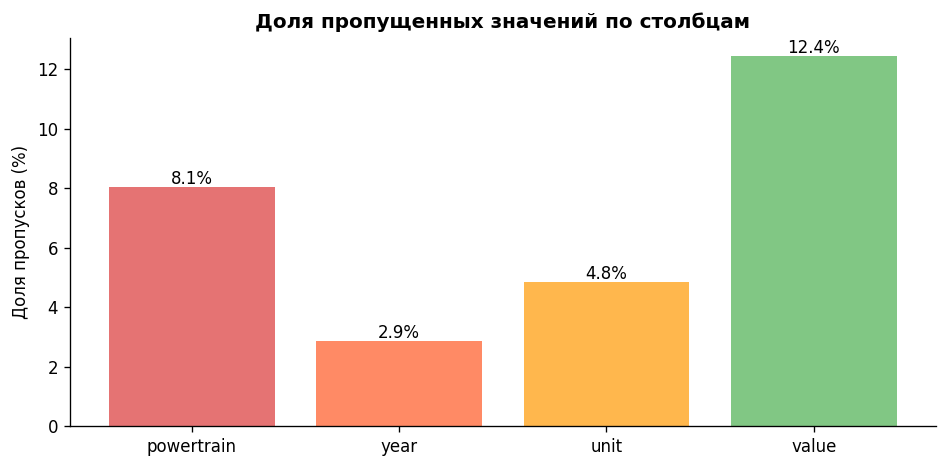

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct_nonzero = missing_pct[missing_pct > 0]
bars = ax.bar(missing_pct_nonzero.index, missing_pct_nonzero.values,
              color=['#E57373', '#FF8A65', '#FFB74D', '#81C784'])
ax.set_ylabel('Доля пропусков (%)')
ax.set_title('Доля пропущенных значений по столбцам', fontweight='bold')
for bar, val in zip(bars, missing_pct_nonzero.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### 2.2 Визуализация карты пропусков

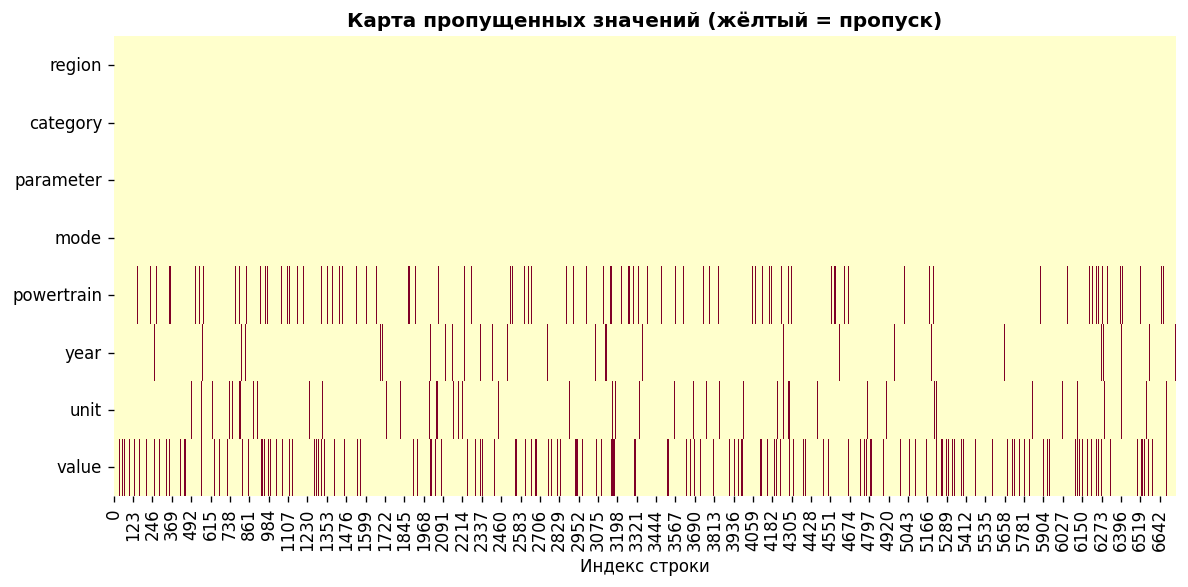

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.isnull().T, cmap='YlOrRd', cbar=False,
            yticklabels=df.columns, ax=ax)
ax.set_title('Карта пропущенных значений (жёлтый = пропуск)', fontweight='bold')
ax.set_xlabel('Индекс строки')
plt.tight_layout()
plt.show()


### 2.3 Стратегии заполнения пропусков

| Столбец | Тип | Стратегия |
|---------|-----|-----------|
| `value` | числовой | Медиана внутри группы `parameter` |
| `year` | числовой | Медиана (год — дискретное целое) |
| `powertrain` | категориальный | Мода внутри группы `mode` |
| `unit` | категориальный | Мода внутри группы `parameter` |


In [8]:
df_clean = df.copy()

# --- value: медиана внутри группы parameter ---
df_clean['value'] = (
    df_clean.groupby('parameter')['value']
    .transform(lambda x: x.fillna(x.median()))
)
# Если после групповой медианы остались пропуски — глобальная медиана
df_clean['value'] = df_clean['value'].fillna(df_clean['value'].median())

# --- year: медиана (целое число) ---
year_median = int(df_clean['year'].median())
df_clean['year'] = df_clean['year'].fillna(year_median).astype(int)

# --- powertrain: мода внутри группы mode ---
def fill_mode(series):
    mode = series.mode()
    return series.fillna(mode[0] if len(mode) > 0 else 'Unknown')

df_clean['powertrain'] = df_clean.groupby('mode')['powertrain'].transform(fill_mode)

# --- unit: мода внутри группы parameter ---
df_clean['unit'] = df_clean.groupby('parameter')['unit'].transform(fill_mode)

# Проверка
print("Пропуски после обработки:")
print(df_clean.isnull().sum())


Пропуски после обработки:
region        0
category      0
parameter     0
mode          0
powertrain    0
year          0
unit          0
value         0
dtype: int64


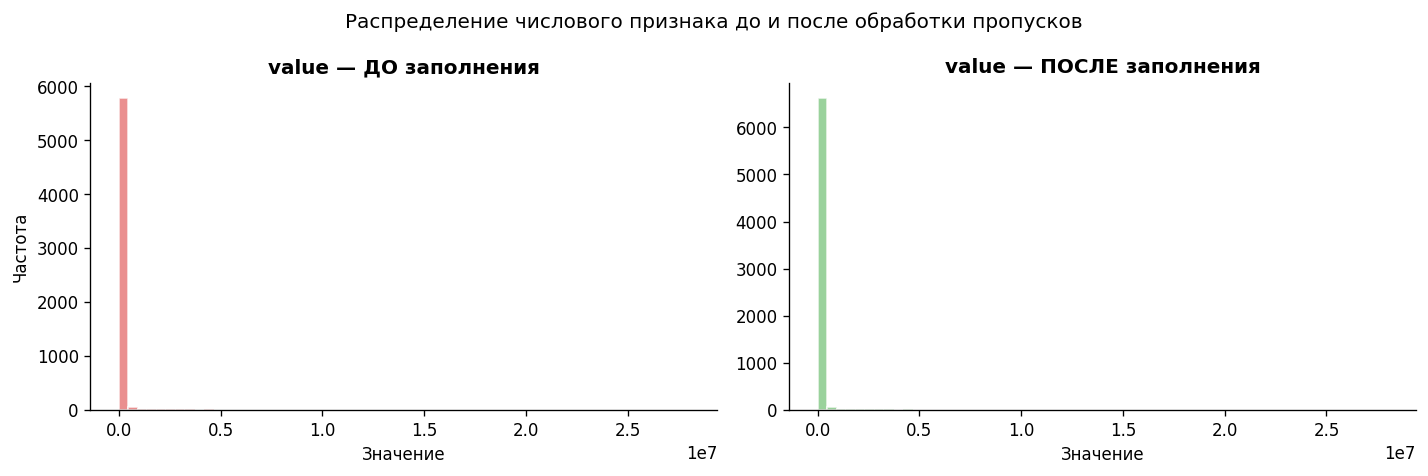

Пропусков до:  840
Пропусков после: 0


In [ ]:
# Сравнение распределения value до и после
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['value'].dropna(), bins=60, color='#E57373', alpha=0.8, edgecolor='white')
axes[0].set_title('value — ДО заполнения', fontweight='bold')
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Частота')

axes[1].hist(df_clean['value'], bins=60, color='#81C784', alpha=0.8, edgecolor='white')
axes[1].set_title('value — ПОСЛЕ заполнения', fontweight='bold')
axes[1].set_xlabel('Значение')

plt.suptitle('Распределение числового признака до и после обработки пропусков', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Пропусков до:  {df['value'].isnull().sum()}")
print(f"Пропусков после: {df_clean['value'].isnull().sum()}")


---
## 3. Кодирование категориальных признаков

Категориальные столбцы датасета: `region`, `category`, `parameter`, `mode`, `powertrain`, `unit`.

Применим три подхода:
- **Label Encoding** — для бинарных / порядковых признаков (`category`, `mode`)
- **Ordinal Encoding** — для `powertrain` (BEV < PHEV < FCEV — условная иерархия)
- **One-Hot Encoding** — для `parameter` и `unit` (нет порядка, умеренное число классов)

> Столбец `region` (много уникальных значений) оставим как есть или применим Target Encoding при необходимости.


In [10]:
print("Уникальных значений по категориальным признакам:")
cat_cols = ['region', 'category', 'parameter', 'mode', 'powertrain', 'unit']
for c in cat_cols:
    print(f"  {c:15s}: {df_clean[c].nunique():3d}  → {sorted(df_clean[c].unique())[:5]} ...")


Уникальных значений по категориальным признакам:
  region         :  52  → ['Australia', 'Austria', 'Belgium', 'Brazil', 'Bulgaria'] ...
  category       :   1  → ['Historical'] ...
  parameter      :   4  → ['EV sales', 'EV sales share', 'EV stock', 'EV stock share'] ...
  mode           :   3  → ['Buses', 'Cars', 'Vans'] ...
  powertrain     :   4  → ['BEV', 'EV', 'FCEV', 'PHEV'] ...
  unit           :   2  → ['Vehicles', 'percent'] ...


### 3.1 Label Encoding (`category`, `mode`)

In [11]:
df_encoded = df_clean.copy()
le = LabelEncoder()

# category
df_encoded['category_le'] = le.fit_transform(df_encoded['category'])
print("category →", dict(zip(le.classes_, le.transform(le.classes_))))

# mode
df_encoded['mode_le'] = le.fit_transform(df_encoded['mode'])
print("mode     →", dict(zip(le.classes_, le.transform(le.classes_))))

df_encoded[['category', 'category_le', 'mode', 'mode_le']].drop_duplicates().reset_index(drop=True)


category → {'Historical': 0}
mode     → {'Buses': 0, 'Cars': 1, 'Vans': 2}


,category,category_le,mode,mode_le
0,Historical,0,Cars,1
1,Historical,0,Buses,0
2,Historical,0,Vans,2


### 3.2 Ordinal Encoding (`powertrain`)

In [12]:
powertrain_order = [['BEV', 'PHEV', 'FCEV', 'EV']]  # условная ординальная шкала
oe = OrdinalEncoder(categories=powertrain_order,
                    handle_unknown='use_encoded_value', unknown_value=-1)

df_encoded['powertrain_oe'] = oe.fit_transform(df_encoded[['powertrain']])

print("Ordinal Encoding (powertrain):")
print(df_encoded[['powertrain', 'powertrain_oe']].drop_duplicates().sort_values('powertrain_oe').to_string(index=False))


Ordinal Encoding (powertrain):
powertrain  powertrain_oe
       BEV            0.0
      PHEV            1.0
      FCEV            2.0
        EV            3.0


### 3.3 One-Hot Encoding (`parameter`, `unit`)

In [13]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)

ohe_param = ohe.fit_transform(df_encoded[['parameter']])
ohe_param_df = pd.DataFrame(ohe_param,
                             columns=[f'param_{c}' for c in ohe.categories_[0]],
                             index=df_encoded.index)

ohe_unit = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)
ohe_u = ohe_unit.fit_transform(df_encoded[['unit']])
ohe_unit_df = pd.DataFrame(ohe_u,
                            columns=[f'unit_{c}' for c in ohe_unit.categories_[0]],
                            index=df_encoded.index)

df_encoded = pd.concat([df_encoded, ohe_param_df, ohe_unit_df], axis=1)

print(f"Новые столбцы OHE (parameter): {list(ohe_param_df.columns)}")
print(f"Новые столбцы OHE (unit):      {list(ohe_unit_df.columns)}")
print(f"\nИтоговый размер датасета: {df_encoded.shape}")
df_encoded.head(3)


Новые столбцы OHE (parameter): ['param_EV sales', 'param_EV sales share', 'param_EV stock', 'param_EV stock share']
Новые столбцы OHE (unit):      ['unit_Vehicles', 'unit_percent']

Итоговый размер датасета: (6746, 17)


,region,category,parameter,mode,powertrain,year,unit,value,category_le,mode_le,powertrain_oe,param_EV sales,param_EV sales share,param_EV stock,param_EV stock share,unit_Vehicles,unit_percent
0,Australia,Historical,EV stock share,Cars,EV,2011,percent,0.00039,0,1,3.0,0,0,0,1,0,1
1,Australia,Historical,EV sales share,Cars,BEV,2011,percent,0.00650,0,1,0.0,0,1,0,0,0,1
2,Australia,Historical,EV sales,Cars,BEV,2011,Vehicles,49.00000,0,1,0.0,1,0,0,0,1,0


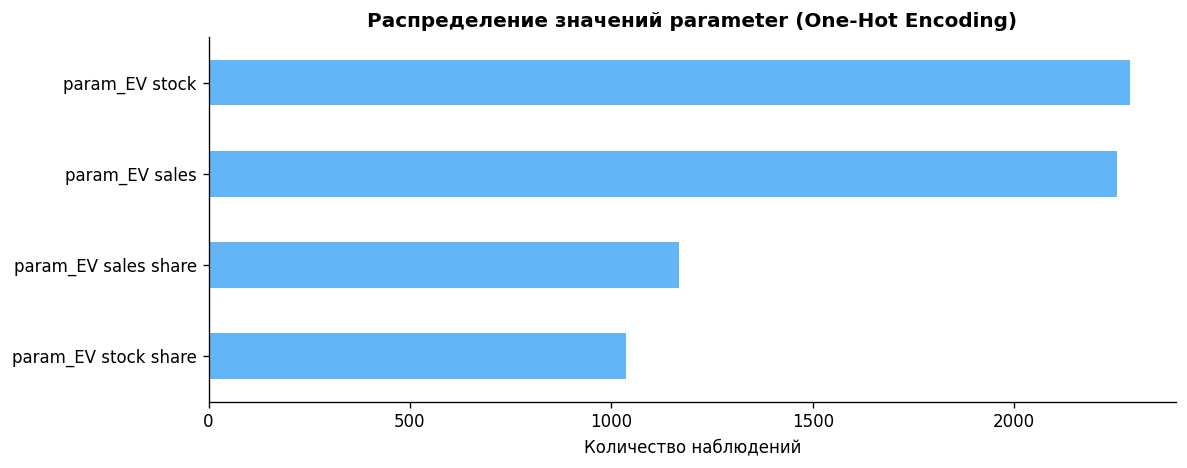

In [ ]:
# Визуализация распределения OHE-признаков parameter
fig, ax = plt.subplots(figsize=(10, 4))
ohe_param_df.sum().sort_values(ascending=True).plot(kind='barh', ax=ax, color='#64B5F6')
ax.set_xlabel('Количество наблюдений')
ax.set_title('Распределение значений parameter (One-Hot Encoding)', fontweight='bold')
plt.tight_layout()
plt.show()


---
## 4. Масштабирование данных

Применим три метода масштабирования к числовым признакам `value` и `year`:

| Метод | Формула | Когда применять |
|-------|---------|-----------------|
| **MinMaxScaler** | \(x' = \frac{x - x_{min}}{x_{max} - x_{min}}\) | Равномерное распределение, нет выбросов |
| **StandardScaler** | \(x' = \frac{x - \mu}{\sigma}\) | Нормальное распределение, линейные модели |
| **RobustScaler** | \(x' = \frac{x - Q_2}{Q_3 - Q_1}\) | Есть выбросы (используется IQR) |


In [15]:
numeric_cols = ['value', 'year']
X_num = df_encoded[numeric_cols].copy()

scalers = {
    'MinMaxScaler':   MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'RobustScaler':   RobustScaler(),
}

scaled_results = {}
for name, scaler in scalers.items():
    scaled = scaler.fit_transform(X_num)
    scaled_results[name] = pd.DataFrame(scaled, columns=[f'{c}_{name[:3]}' for c in numeric_cols])
    print(f"{name}:")
    print(pd.DataFrame(scaled, columns=numeric_cols).describe().round(4), "\n")


MinMaxScaler:
           value       year
count  6746.0000  6746.0000
mean      0.0020     0.5889
std       0.0216     0.2855
min       0.0000     0.0000
25%       0.0000     0.3846
50%       0.0000     0.6154
75%       0.0000     0.8462
max       1.0000     1.0000 

StandardScaler:
           value       year
count  6746.0000  6746.0000
mean     -0.0000     0.0000
std       1.0001     1.0001
min      -0.0925    -2.0630
25%      -0.0925    -0.7156
50%      -0.0923     0.0928
75%      -0.0905     0.9013
max      46.1026     1.4403 

RobustScaler:
            value       year
count   6746.0000  6746.0000
mean      46.6910    -0.0574
std      505.6470     0.6185
min       -0.0667    -1.3333
25%       -0.0657    -0.5000
50%        0.0000     0.0000
75%        0.9343     0.5000
max    23356.6233     0.8333 



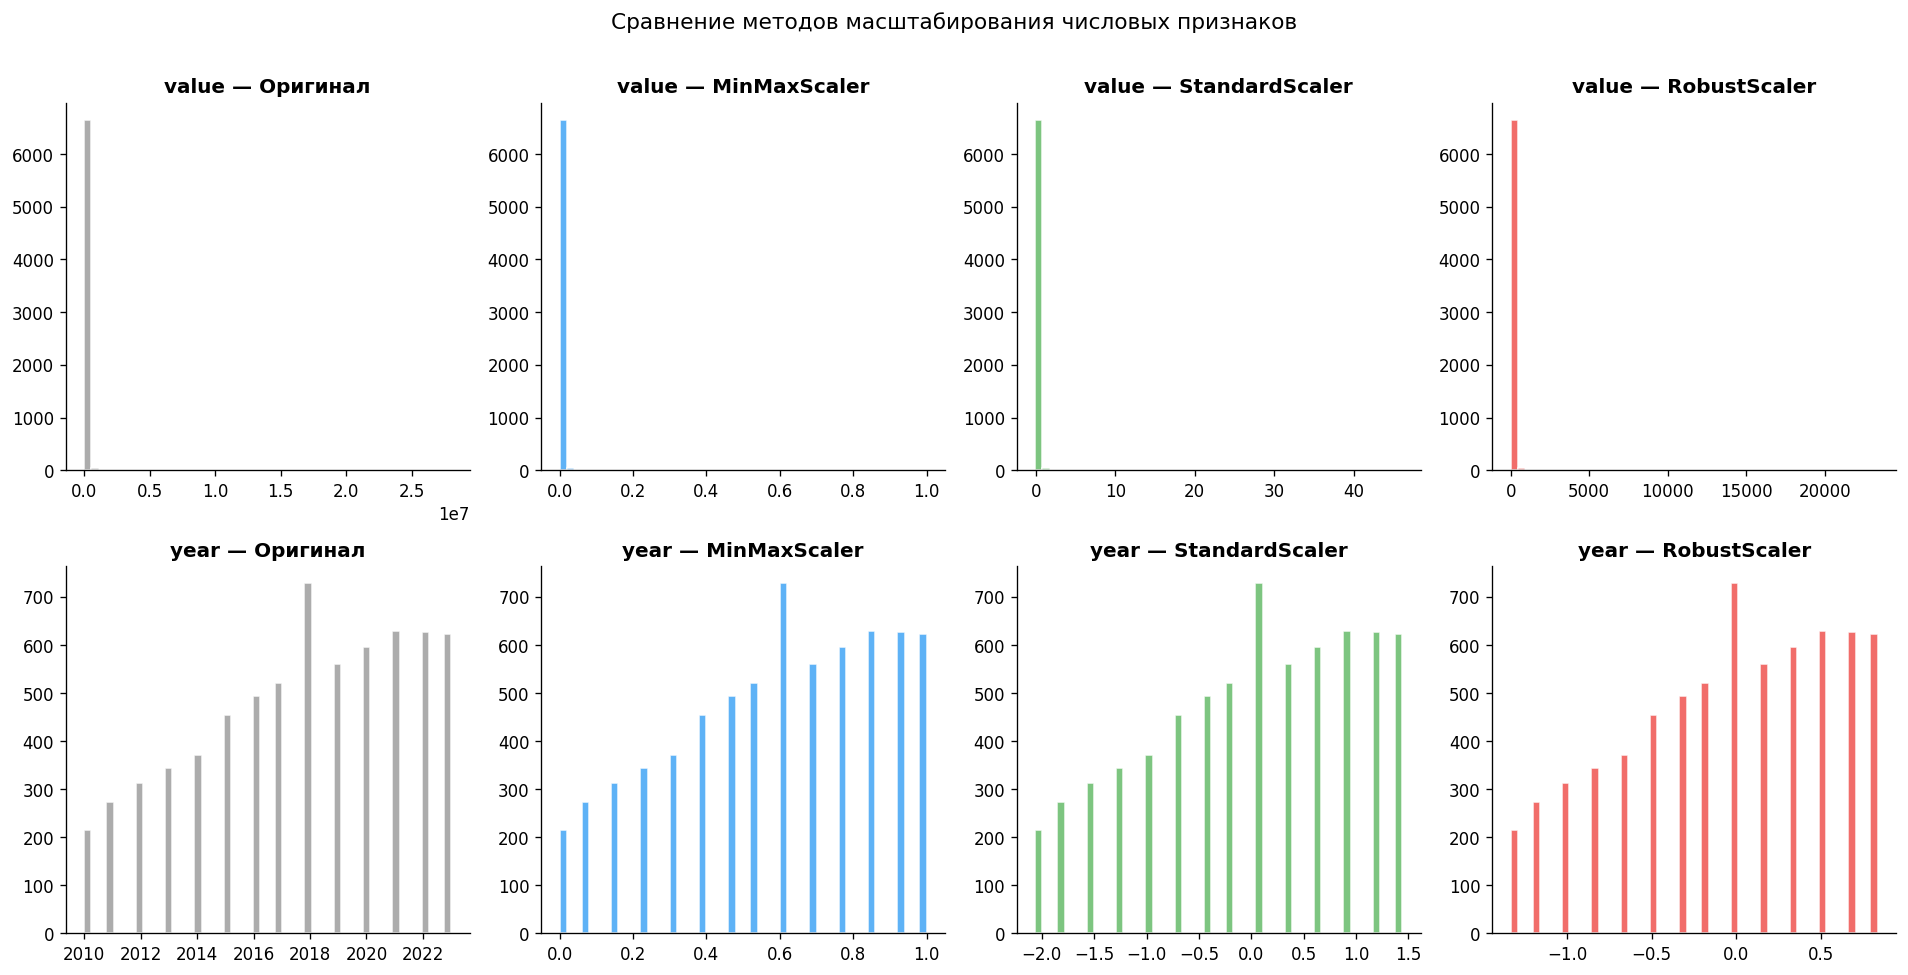

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
colors = ['#9E9E9E', '#42A5F5', '#66BB6A', '#EF5350']

for col_i, col in enumerate(numeric_cols):
    # оригинал
    axes[col_i, 0].hist(X_num[col], bins=50, color=colors[0], edgecolor='white', alpha=0.85)
    axes[col_i, 0].set_title(f'{col} — Оригинал', fontweight='bold')

    for scaler_i, (name, result_df) in enumerate(scaled_results.items(), start=1):
        key = f'{col}_{name[:3]}'
        axes[col_i, scaler_i].hist(result_df[key], bins=50, color=colors[scaler_i],
                                    edgecolor='white', alpha=0.85)
        axes[col_i, scaler_i].set_title(f'{col} — {name}', fontweight='bold')

plt.suptitle('Сравнение методов масштабирования числовых признаков', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [17]:
# Итоговый датасет со StandardScaler (рекомендуется для большинства ML-моделей)
scaler_final = StandardScaler()
df_encoded[['value_scaled', 'year_scaled']] = scaler_final.fit_transform(X_num)

print("Финальный набор признаков:")
final_cols = (['region', 'category_le', 'mode_le', 'powertrain_oe']
              + list(ohe_param_df.columns)
              + list(ohe_unit_df.columns)
              + ['value_scaled', 'year_scaled'])
df_final = df_encoded[final_cols]
print(f"Размер: {df_final.shape}")
df_final.head()


Финальный набор признаков:
Размер: (6746, 12)


,region,category_le,mode_le,powertrain_oe,param_EV sales,param_EV sales share,param_EV stock,param_EV stock share,unit_Vehicles,unit_percent,value_scaled,year_scaled
0,Australia,0,1,3.0,0,0,0,1,0,1,-0.092478,-1.793542
1,Australia,0,1,0.0,0,1,0,0,0,1,-0.092478,-1.793542
2,Australia,0,1,0.0,1,0,0,0,1,0,-0.092397,-1.793542
3,Australia,0,1,0.0,0,0,1,0,1,0,-0.092397,-1.793542
4,Australia,0,1,0.0,0,0,1,0,1,0,-0.092115,-1.524059


In [18]:
# Сохранение итогового обработанного датасета
df_final.to_csv('IEA_EV_Data_preprocessed.csv', index=False)
print("Сохранён: IEA_EV_Data_preprocessed.csv")


Сохранён: IEA_EV_Data_preprocessed.csv


---
## 5. Итоги предобработки

| Этап | Метод | Результат |
|------|-------|-----------|
| **Пропуски** | Медиана по группам (`value`, `year`), мода по группам (`powertrain`, `unit`) | 0 пропусков |
| **Кодирование** | Label Encoding (`category`, `mode`), Ordinal Encoding (`powertrain`), One-Hot Encoding (`parameter`, `unit`) | Все признаки числовые |
| **Масштабирование** | StandardScaler для `value` и `year` | μ≈0, σ≈1 |
